In [1]:
import torch
from torch.distributions import Normal

import sys
sys.path.append('../../drnpe')
sys.path.append('.')

import lightning

from hydra import compose, initialize
from hydra.utils import instantiate

import matplotlib.pyplot as plt

device = torch.device("cuda:7" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda:7


### **Plot aesthetics**

In [2]:
npe_color = "#cca90e"
drnpe_color = "#374a99"
axis_label_size = 16
tick_label_size = 8

### **Well-specified simulator**

**Generate data and compute true posterior intervals:**

In [3]:
with initialize(version_base=None, config_path="conf"):
    cfg_npe = compose(config_name="config_npe_flow")
    cfg_drnpe = compose(config_name="config_drnpe_flow")

lightning.seed_everything(cfg_npe.seed)

datamodule = instantiate(cfg_npe.datamodule)

Seed set to 42


In [4]:
n = 1000
num_obs = datamodule.num_observations
prior_stdev = datamodule.prior_stdev
likelihood_stdev = 1.0

In [5]:
z = Normal(0.0, prior_stdev).sample([n]).to(device)
x_raw = Normal(z, likelihood_stdev).sample(
    [datamodule.num_observations]
).permute(1, 0)
xbar = x_raw.mean(dim=1, keepdim=True)
samplevar = x_raw.var(dim=1, unbiased=False, keepdim=True)
x = torch.cat([xbar, samplevar], dim=1)

In [6]:
sigma_post_sq = 1.0 / (1.0 / prior_stdev**2 + num_obs / likelihood_stdev**2)
sigma_post = sigma_post_sq ** 0.5

mu_post = sigma_post_sq * (num_obs * xbar.squeeze() / likelihood_stdev**2)

z_crit = Normal(0.0, 1.0).icdf(torch.tensor(0.95)).item()

true_lower = mu_post - z_crit * sigma_post
true_upper = mu_post + z_crit * sigma_post

**Generate NPE posterior samples**

In [7]:
encoder_npe = instantiate(cfg_npe.encoder)
state_dict = torch.load(
    "../../trained_ckpts/network_npe_flow.ckpt", map_location=device
)['state_dict']
encoder_npe.load_state_dict(state_dict)
encoder_npe = encoder_npe.to(device).eval()

num_npe_samples = 10000

with torch.inference_mode():
    with torch.no_grad():
        npe_samples = encoder_npe.flow.sample(num_npe_samples, x)
        npe_samples = npe_samples.squeeze(-1)

**Generate DRNPE posterior samples**

In [8]:
encoder_drnpe = instantiate(cfg_drnpe.encoder)
state_dict = torch.load(
    "../../trained_ckpts/network_drnpe_dual_flow.ckpt", map_location=device
)['state_dict']
encoder_drnpe.load_state_dict(state_dict)
encoder_drnpe = encoder_drnpe.to(device).eval()

with torch.inference_mode():
    with torch.no_grad():
        drnpe_samples = encoder_drnpe.flow.sample(num_npe_samples, x)
        drnpe_samples = drnpe_samples.squeeze(-1)

**Define nominal coverage levels**

In [9]:
nominal = torch.linspace(0.05, 0.95, steps=19)
lower_q = (1 - nominal) / 2
upper_q = 1 - lower_q

**Compute NPE and DRNPE coverage**

In [10]:
npe_lo = torch.quantile(npe_samples, lower_q.to(device), dim=1).T
npe_hi = torch.quantile(npe_samples, upper_q.to(device), dim=1).T
npe_cov = ((z.unsqueeze(-1) >= npe_lo) * (z.unsqueeze(-1) <= npe_hi)).float().mean(0)

drnpe_lo = torch.quantile(drnpe_samples, lower_q.to(device), dim=1).T
drnpe_hi = torch.quantile(drnpe_samples, upper_q.to(device), dim=1).T
drnpe_cov = ((z.unsqueeze(-1) >= drnpe_lo) * (z.unsqueeze(-1) <= drnpe_hi)).float().mean(0)

**Plot nominal vs. empirical coverage**

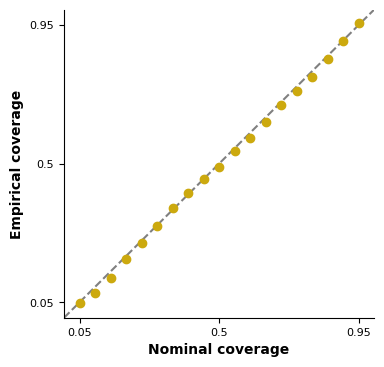

In [11]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
_ = ax.axline((0, 0), slope = 1, color = "gray", linestyle = "dashed", zorder = 0)
_ = ax.scatter(nominal.cpu(), npe_cov.cpu(), color=npe_color, zorder = 1)
_ = ax.set_xlabel("Nominal coverage", fontweight = "bold")
_ = ax.set_ylabel("Empirical coverage", fontweight = "bold")
_ = ax.spines[["top", "right"]].set_visible(False)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1)
_ = ax.set_xticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.set_yticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.tick_params(axis="both", which="major", labelsize=tick_label_size)
fig.savefig("figures/npe_coverage_wellspecified.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

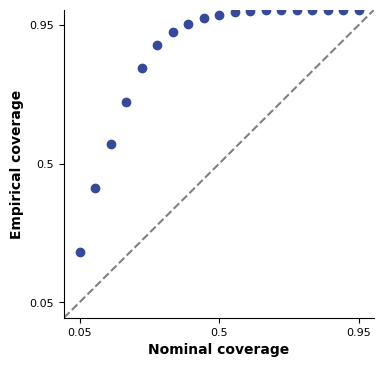

In [12]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
_ = ax.axline((0, 0), slope = 1, color = "gray", linestyle = "dashed", zorder = 0)
_ = ax.scatter(nominal.cpu(), drnpe_cov.cpu(), color=drnpe_color, zorder = 1)
_ = ax.set_xlabel("Nominal coverage", fontweight = "bold")
_ = ax.set_ylabel("Empirical coverage", fontweight = "bold")
_ = ax.spines[["top", "right"]].set_visible(False)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1)
_ = ax.set_xticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.set_yticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.tick_params(axis="both", which="major", labelsize=tick_label_size)
fig.savefig("figures/drnpe_coverage_wellspecified.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

### **Misspecified simulator**

**Generate data and compute true posterior intervals:**

In [13]:
likelihood_stdev = 2.0

In [14]:
z = Normal(0.0, prior_stdev).sample([n]).to(device)
x_raw = Normal(z, likelihood_stdev).sample(
    [datamodule.num_observations]
).permute(1, 0)
xbar = x_raw.mean(dim=1, keepdim=True)
samplevar = x_raw.var(dim=1, unbiased=False, keepdim=True)
x = torch.cat([xbar, samplevar], dim=1)

In [15]:
sigma_post_sq = 1.0 / (1.0 / prior_stdev**2 + num_obs / likelihood_stdev**2)
sigma_post = sigma_post_sq ** 0.5

mu_post = sigma_post_sq * (num_obs * xbar.squeeze() / likelihood_stdev**2)

z_crit = Normal(0.0, 1.0).icdf(torch.tensor(0.95)).item()

true_lower = mu_post - z_crit * sigma_post
true_upper = mu_post + z_crit * sigma_post

**Generate NPE posterior samples**

In [16]:
with torch.inference_mode():
    with torch.no_grad():
        npe_samples = encoder_npe.flow.sample(num_npe_samples, x)
        npe_samples = npe_samples.squeeze(-1)

**Generate DRNPE posterior samples**

In [17]:
with torch.inference_mode():
    with torch.no_grad():
        drnpe_samples = encoder_drnpe.flow.sample(num_npe_samples, x)
        drnpe_samples = drnpe_samples.squeeze(-1)

**Compute NPE and DNRPE coverage**

In [18]:
npe_lo = torch.quantile(npe_samples, lower_q.to(device), dim=1).T
npe_hi = torch.quantile(npe_samples, upper_q.to(device), dim=1).T
npe_cov = ((z.unsqueeze(-1) >= npe_lo) * (z.unsqueeze(-1) <= npe_hi)).float().mean(0)

drnpe_lo = torch.quantile(drnpe_samples, lower_q.to(device), dim=1).T
drnpe_hi = torch.quantile(drnpe_samples, upper_q.to(device), dim=1).T
drnpe_cov = ((z.unsqueeze(-1) >= drnpe_lo) * (z.unsqueeze(-1) <= drnpe_hi)).float().mean(0)

**Plot nominal vs. empirical coverage**

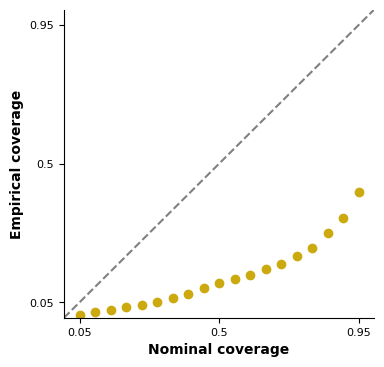

In [19]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
_ = ax.axline((0, 0), slope = 1, color = "gray", linestyle = "dashed", zorder = 0)
_ = ax.scatter(nominal.cpu(), npe_cov.cpu(), color=npe_color, zorder = 1)
_ = ax.set_xlabel("Nominal coverage", fontweight = "bold")
_ = ax.set_ylabel("Empirical coverage", fontweight = "bold")
_ = ax.spines[["top", "right"]].set_visible(False)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1)
_ = ax.set_xticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.set_yticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.tick_params(axis="both", which="major", labelsize=tick_label_size)
fig.savefig("figures/npe_coverage_misspecified.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)

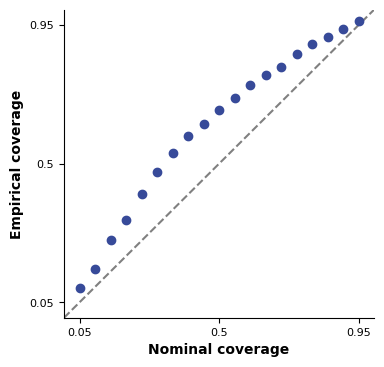

In [20]:
fig, ax = plt.subplots(1, 1, figsize = (4, 4))
_ = ax.axline((0, 0), slope = 1, color = "gray", linestyle = "dashed", zorder = 0)
_ = ax.scatter(nominal.cpu(), drnpe_cov.cpu(), color=drnpe_color, zorder = 1)
_ = ax.set_xlabel("Nominal coverage", fontweight = "bold")
_ = ax.set_ylabel("Empirical coverage", fontweight = "bold")
_ = ax.spines[["top", "right"]].set_visible(False)
_ = ax.set_xlim(0, 1)
_ = ax.set_ylim(0, 1)
_ = ax.set_xticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.set_yticks([0.05, 0.5, 0.95], [0.05, 0.5, 0.95])
_ = ax.tick_params(axis="both", which="major", labelsize=tick_label_size)
fig.savefig("figures/drnpe_coverage_misspecified.png", dpi=600, transparent=True, bbox_inches="tight", pad_inches=0)